# Lazy Browse — DestinE Climate DT Portfolio

This notebook provides an **instant xarray view** of DestinE Climate DT data.
Variables and coordinates appear immediately — actual data is fetched from
Polytope **only when you access values** (e.g. plotting, `.values`, `.compute()`).

Under the hood, `polytope_zarr.PolytopeZarrStore` acts as a virtual Zarr store:
it synthesises Zarr metadata from the declared coordinates and variables, and
intercepts chunk reads to fetch data from Polytope on demand.

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [29]:
import logging, warnings
import earthkit.data

# Cache & logging configuration
earthkit.data.config.set("cache-policy", "temporary")
earthkit.data.config.set("maximum-cache-size", "2G")
for _ln in ("earthkit.data", "polytope", "polytope.api", "polytope_client", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [30]:
import numpy as np
import pandas as pd
from polytope_zarr import PolytopeZarrStore

## 1. Define the dataset

We declare which coordinates, variables, and Polytope request fields to use.
Nothing is downloaded here — the store just builds metadata.

In [31]:
# ── Configuration ──────────────────────────────────────────────────
MODELS       = ["ICON", "IFS-FESOM", "IFS-NEMO"]
EXPERIMENT   = "hist"              # 'hist', 'SSP3-7.0'
RESOLUTION   = "standard"          # nside=128 → 196 608 cells
N_CELLS      = 12 * 128**2         # HEALPix grid size
YEARS        = range(1990, 2020)   # 30-year historical period

# Polytope address per model (IFS-NEMO uses MN5, others use LUMI)
ADDRESS = {
    "ICON":       "polytope.lumi.apps.dte.destination-earth.eu",
    "IFS-FESOM":  "polytope.lumi.apps.dte.destination-earth.eu",
    "IFS-NEMO":   "polytope.mn5.apps.dte.destination-earth.eu",
}

# Infer activity from experiment
ACTIVITY = "baseline" if EXPERIMENT in ("hist", "cont") else "projections"

In [ ]:
# Monthly time axis: one timestamp per month for each year
time_axis = pd.date_range(
    f"{min(YEARS)}-01", f"{max(YEARS)}-12", freq="MS"
)

D = ("model", "time", "cell")

# All Phase 2 clmn surface parameters (levtype=sfc, removed params excluded)
VARIABLES = {
    # ── Single-level / surface atmosphere (from instant params in clte) ──
    "avg_tclw":     {"dims": D, "long_name": "Time-mean total column liquid water",             "units": "kg m**-2"},
    "avg_tciw":     {"dims": D, "long_name": "Time-mean total column cloud ice water",          "units": "kg m**-2"},
    "avg_sp":       {"dims": D, "long_name": "Time-mean surface pressure",                      "units": "Pa"},
    "avg_tcw":      {"dims": D, "long_name": "Time-mean total column water",                    "units": "kg m**-2"},
    "avg_tcwv":     {"dims": D, "long_name": "Time-mean total column water vapour",             "units": "kg m**-2"},
    "avg_sd":       {"dims": D, "long_name": "Time-mean snow depth water equivalent",           "units": "kg m**-2"},
    "avg_msl":      {"dims": D, "long_name": "Time-mean mean sea level pressure",               "units": "Pa"},
    "avg_tcc":      {"dims": D, "long_name": "Time-mean total cloud cover",                     "units": "%"},
    "avg_10u":      {"dims": D, "long_name": "Time-mean 10 metre U wind component",             "units": "m s**-1"},
    "avg_10v":      {"dims": D, "long_name": "Time-mean 10 metre V wind component",             "units": "m s**-1"},
    "avg_2t":       {"dims": D, "long_name": "Time-mean 2 metre temperature",                   "units": "K"},
    "avg_2d":       {"dims": D, "long_name": "Time-mean 2 metre dewpoint temperature",          "units": "K"},
    "avg_10ws":     {"dims": D, "long_name": "Time-mean 10 metre wind speed",                   "units": "m s**-1"},
    "avg_skt":      {"dims": D, "long_name": "Time-mean skin temperature",                      "units": "K"},
    # ── From hourly-mean params in clte ──────────────────────────────────
    "avg_surfror":  {"dims": D, "long_name": "Time-mean surface runoff rate",                   "units": "kg m**-2 s**-1"},
    "avg_ssurfror": {"dims": D, "long_name": "Time-mean sub-surface runoff rate",               "units": "kg m**-2 s**-1"},
    "avg_tsrwe":    {"dims": D, "long_name": "Time-mean total snowfall rate water equivalent",  "units": "kg m**-2 s**-1"},
    "avg_ishf":     {"dims": D, "long_name": "Time-mean surface sensible heat flux",            "units": "W m**-2"},
    "avg_slhtf":    {"dims": D, "long_name": "Time-mean surface latent heat flux",              "units": "W m**-2"},
    "avg_sdswrf":   {"dims": D, "long_name": "Time-mean surface downward short-wave radiation flux",  "units": "W m**-2"},
    "avg_sdlwrf":   {"dims": D, "long_name": "Time-mean surface downward long-wave radiation flux",   "units": "W m**-2"},
    "avg_snswrf":   {"dims": D, "long_name": "Time-mean surface net short-wave radiation flux",       "units": "W m**-2"},
    "avg_snlwrf":   {"dims": D, "long_name": "Time-mean surface net long-wave radiation flux",        "units": "W m**-2"},
    "avg_tnswrf":   {"dims": D, "long_name": "Time-mean top net short-wave radiation flux",     "units": "W m**-2"},
    "avg_tnlwrf":   {"dims": D, "long_name": "Time-mean top net long-wave radiation flux",      "units": "W m**-2"},
    "avg_iews":     {"dims": D, "long_name": "Time-mean eastward turbulent surface stress",     "units": "N m**-2"},
    "avg_inss":     {"dims": D, "long_name": "Time-mean northward turbulent surface stress",    "units": "N m**-2"},
    "avg_ie":       {"dims": D, "long_name": "Time-mean moisture flux",                         "units": "kg m**-2 s**-1"},
    "avg_tnswrfcs": {"dims": D, "long_name": "Time-mean top net short-wave radiation flux, clear sky",     "units": "W m**-2"},
    "avg_tnlwrcs":  {"dims": D, "long_name": "Time-mean top net long-wave radiation flux, clear sky",      "units": "W m**-2"},
    "avg_snswrfcs": {"dims": D, "long_name": "Time-mean surface net short-wave radiation flux, clear sky", "units": "W m**-2"},
    "avg_snlwrcs":  {"dims": D, "long_name": "Time-mean surface net long-wave radiation flux, clear sky",  "units": "W m**-2"},
    "avg_tdswrf":   {"dims": D, "long_name": "Time-mean top downward short-wave radiation flux","units": "W m**-2"},
    "avg_tprate":   {"dims": D, "long_name": "Time-mean total precipitation rate",              "units": "kg m**-2 s**-1"},
}

store = PolytopeZarrStore(
    address=ADDRESS,
    collection="destination-earth",
    base_request={
        "class": "d1",
        "dataset": "climate-dt",
        "type": "fc",
        "expver": "0001",
        "generation": "2",
        "realization": "1",
        "activity": ACTIVITY,
        "experiment": EXPERIMENT,
        "levtype": "sfc",
        "resolution": RESOLUTION,
        "stream": "clmn",
    },
    coords={
        "time":  time_axis,
        "cell":  range(N_CELLS),
        "model": MODELS,
    },
    variables=VARIABLES,
    internal_dims=["cell"],
    time_fields=["year", "month"],  # monthly data → only year+month in request
)
print(store)

<PolytopeZarrStore 34 variables (time=360, cell=196608, model=3)>


## 2. Open as xarray Dataset

This is **instant** — no data downloaded yet. You see all variables,
dimensions, and coordinate values.

In [28]:
ds = store.open()
ds

<xarray.Dataset> Size: 29GB
Dimensions:       (model: 3, time: 360, cell: 196608)
Coordinates:
  * model         (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time          (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2019-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 849MB ...
    avg_10v       (model, time, cell) float32 849MB ...
    avg_10ws      (model, time, cell) float32 849MB ...
    avg_2d        (model, time, cell) float32 849MB ...
    avg_2t        (model, time, cell) float32 849MB ...
    avg_ie        (model, time, cell) float32 849MB ...
    ...            ...
    avg_tnlwrcs   (model, time, cell) float32 849MB ...
    avg_tnlwrf    (model, time, cell) float32 849MB ...
    avg_tnswrf    (model, time, cell) float32 849MB ...
    avg_tnswrfcs  (model, time, cell) float32 849MB ...
    avg_tprate    (model, time, cell) float32 849MB ...
    avg_tsrwe     (model, time, cell) float32 849MB ...

## 3. Plot a single field (triggers lazy fetch)

Only now does the store actually call Polytope — fetching data for the
selected model, time, and variable.

Fetching Frozen({'cell': 196608})...


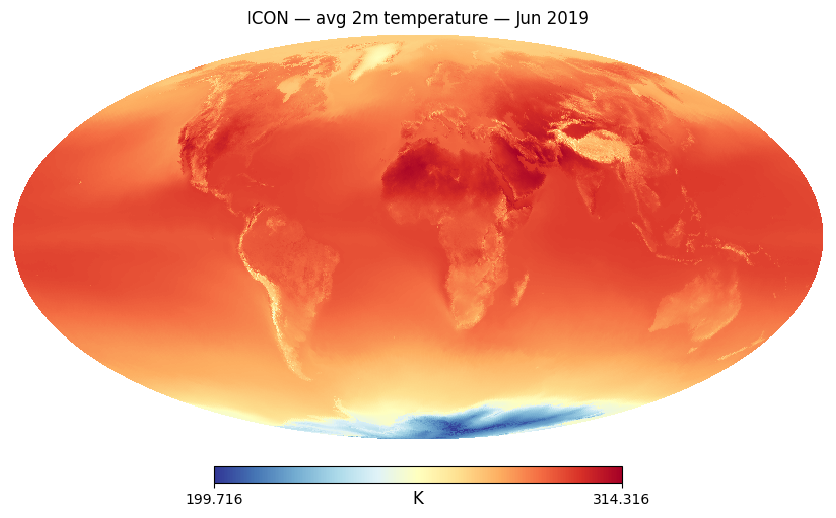

In [14]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["avg_2t"].sel(model="ICON", time="2014-06-01")
print(f"Fetching {field.sizes}...")  # triggers the Polytope request

hp.mollview(field.values, title="ICON — avg 2m temperature — Jun 2019",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

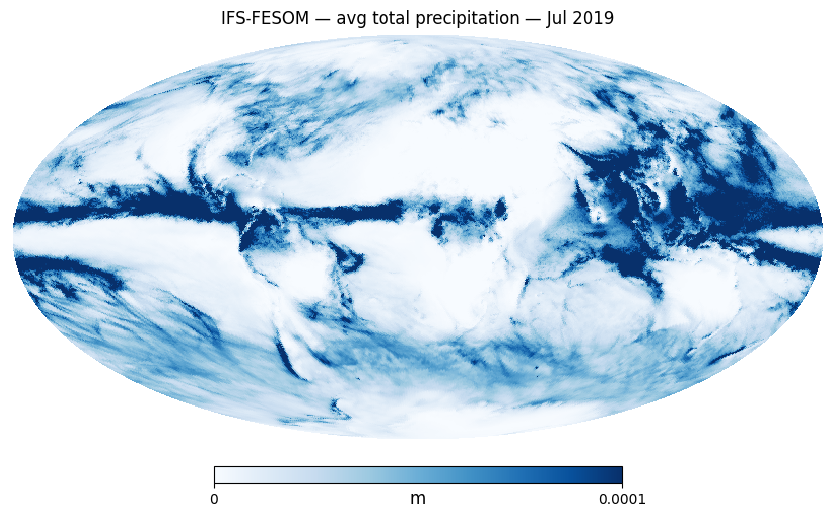

In [18]:
field2 = ds["avg_tprate"].sel(model="IFS-FESOM", time="2014-07-01")

hp.mollview(field2.values,
            title="IFS-FESOM — avg total precipitation — Jul 2019",
            unit="m", cmap="Blues", min=0, max=0.0001, nest=True, flip='geo')
plt.show()

## 4. Compare experiments: climate change signal

Create a second store for the scenario experiment, then take the difference.
Each `.sel()` triggers a single Polytope fetch.

In [ ]:
SCEN_EXPERIMENT = "SSP3-7.0"
SCEN_YEARS      = range(2020, 2050)

scen_store = PolytopeZarrStore(
    address=ADDRESS,
    collection="destination-earth",
    base_request={
        "class": "d1",
        "dataset": "climate-dt",
        "type": "fc",
        "expver": "0001",
        "generation": "2",
        "realization": "1",
        "activity": "projections",
        "experiment": SCEN_EXPERIMENT,
        "levtype": "sfc",
        "resolution": RESOLUTION,
        "stream": "clmn",
    },
    coords={
        "time":  pd.date_range(f"{min(SCEN_YEARS)}-01", f"{max(SCEN_YEARS)}-12", freq="MS"),
        "cell":  range(N_CELLS),
        "model": MODELS,
    },
    variables=VARIABLES,  # same full portfolio
    internal_dims=["cell"],
    time_fields=["year", "month"],
)

ds_scen = scen_store.open()
ds_scen

<xarray.Dataset> Size: 850MB
Dimensions:  (model: 3, time: 360, cell: 196608)
Coordinates:
  * model    (model) object 24B 'ICON' 'IFS-FESOM' 'IFS-NEMO'
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-02-01 ... 2049-12-01
  * cell     (cell) int32 786kB 0 1 2 3 4 ... 196603 196604 196605 196606 196607
Data variables:
    avg_2t   (model, time, cell) float32 849MB ...

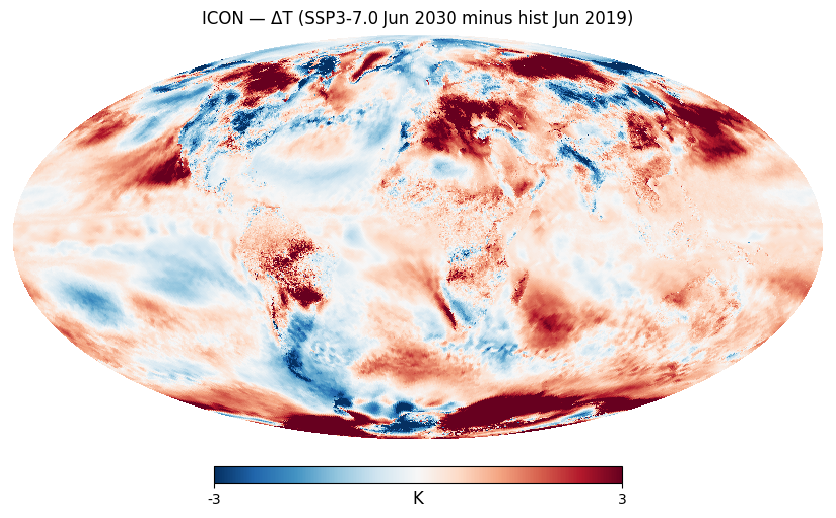

In [21]:
# Single-month comparison: June 2014 (hist) vs June 2030 (scenario)
hist_field = ds["avg_2t"].sel(model="ICON", time="2014-06-01")
scen_field = ds_scen["avg_2t"].sel(model="ICON", time="2030-06-01")

diff = scen_field.values - hist_field.values

hp.mollview(diff,
            title="ICON — ΔT (SSP3-7.0 Jun 2030 minus hist Jun 2019)",
            unit="K", cmap="RdBu_r", min=-3, max=3, nest=True, flip='geo')
plt.show()

## Notes

- **One Polytope request per field** (1 model × 1 month × all cells).
  Great for browsing; for bulk 30-year means, use `02_climate_change_destine.ipynb`
  which batches multiple years per request.
- Add more variables to the `variables` dict to expand the portfolio over time.
- `store.clear_cache()` frees memory from previously fetched fields.

In [22]:
# Free memory if needed
store.clear_cache()
scen_store.clear_cache()